<a href="https://colab.research.google.com/github/DKcit/CT300_bai1/blob/main/VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from os import listdir
import cv2
import numpy as np
import pickle
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
# Import TensorFlow first, then import Keras components via tensorflow.keras
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import random

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
raw_folder = "/content/drive/MyDrive/data/"

1146
1306
574
1162
Total Dataset: 4188


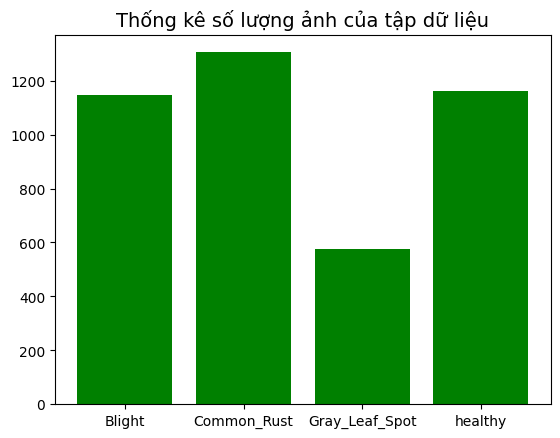

In [ ]:
#Thong ke so luong hinh anh
import time
import os
from os.path import exists
import pandas as pd
def count(dir, counter=0):
    "returns number of files in dir and subdirs"
    for pack in os.walk(dir):
        for f in pack[2]:
            counter += 1
    return counter

number_data1 = count('/content/drive/MyDrive/data/Blight')
number_data2 = count('/content/drive/MyDrive/data/Common_Rust')
number_data3 = count('/content/drive/MyDrive/data/Gray_Leaf_Spot')
number_data4 = count('/content/drive/MyDrive/data/Healthy')


print(number_data1)
print(number_data2)
print(number_data3)
print(number_data4)
print("Total Dataset:", number_data1+number_data2+number_data3+number_data4)
x = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'healthy']
y = [number_data1, number_data2, number_data3, number_data4]
Data = {'Dataset': x,
        'Data': y}
df = pd.DataFrame(Data,columns=['Dataset','Data'])

New_Colors = ['green','green','green', 'green']
plt.bar(df['Dataset'], df['Data'], color=New_Colors, width = 0.8)
plt.title('Thống kê số lượng ảnh của tập dữ liệu', fontsize=14)
plt.show()

In [ ]:
def save_data(raw_folder=raw_folder):
  dest_size = (224, 244)
  print("Preprocessing Image...")

  pixels = []
  labels= []

  # Lap qua cac folder con trong thu muc raw
  for folder in listdir(raw_folder):
    if folder != '.DS_Store':
      print("Folder =", folder)
      # Lap qua cac file trong tung thu muc chua cac anh
      for file in listdir(raw_folder + folder):
        if file != '.DS_Store':
          print("File =", file)
          pixels.append(cv2.resize(cv2.imread(raw_folder  + folder +"/" + file),dsize=(224,224)))
          labels.append(folder)

  pixels = np.array(pixels)
  labels = np.array(labels)#.reshape(-1,1)

  from sklearn.preprocessing import LabelBinarizer
  encoder = LabelBinarizer()
  labels = encoder.fit_transform(labels)
  print(labels)

  os.makedirs('/content/drive/MyDrive/VGG16', exist_ok=True)
  file = open('/content/drive/MyDrive/VGG16/pix.data', 'wb')

  # dump information to that file
  pickle.dump((pixels,labels), file)
  # close the file
  file.close()

  return

In [ ]:
def load_data():
    file = open('/content/drive/MyDrive/VGG16/pix.data', 'rb')

    # load cac du lieu hinh anh va nhan
    (pixels, labels) = pickle.load(file)

    # giai phong tap tin
    file.close()

    print(pixels.shape)
    print(labels.shape)

    return pixels, labels

In [ ]:
save_data()
#Luu du lieu vao file pix.data

Preprocessing Image...
Folder = Blight
File = Corn_Blight (632).JPG
File = Corn_Blight (499).JPG
File = Corn_Blight (526).JPG
File = Corn_Blight (308).JPG
File = Corn_Blight (536).JPG
File = Corn_Blight (3).jpg
File = Corn_Blight (564).JPG
File = Corn_Blight (592).JPG
File = Corn_Blight (562).JPG
File = Corn_Blight (40).jpg
File = Corn_Blight (530).JPG
File = Corn_Blight (425).JPG
File = Corn_Blight (429).JPG
File = Corn_Blight (569).JPG
File = Corn_Blight (602).JPG
File = Corn_Blight (297).JPG
File = Corn_Blight (395).JPG
File = Corn_Blight (64).jpg
File = Corn_Blight (284).jpg
File = Corn_Blight (406).JPG
File = Corn_Blight (206).JPG
File = Corn_Blight (457).JPG
File = Corn_Blight (118).JPG
File = Corn_Blight (207).JPG
File = Corn_Blight (439).jpg
File = Corn_Blight (468).JPG
File = Corn_Blight (282).JPG
File = Corn_Blight (443).JPG
File = Corn_Blight (243).JPG
File = Corn_Blight (143).JPG
File = Corn_Blight (43).jpg
File = Corn_Blight (596).JPG
File = Corn_Blight (322).JPG
File = Co

In [ ]:
#Load du lieu
X, y = load_data()

(4188, 224, 224, 3)
(4188, 4)


In [ ]:
print(X)
print(y)

[[[[185 167 174]
   [185 167 174]
   [185 167 174]
   ...
   [140 124 131]
   [144 128 135]
   [137 121 128]]

  [[186 168 175]
   [186 168 175]
   [186 168 175]
   ...
   [138 122 129]
   [140 124 131]
   [145 129 136]]

  [[187 168 175]
   [187 168 175]
   [187 168 175]
   ...
   [142 126 133]
   [139 122 129]
   [153 137 144]]

  ...

  [[161 153 165]
   [159 154 163]
   [157 156 165]
   ...
   [149 143 154]
   [149 143 154]
   [148 143 153]]

  [[129 122 131]
   [138 132 139]
   [149 146 152]
   ...
   [150 144 155]
   [149 143 154]
   [147 141 152]]

  [[ 49  42  49]
   [ 80  73  80]
   [117 114 119]
   ...
   [145 139 150]
   [140 134 145]
   [134 128 139]]]


 [[[142 130 136]
   [141 129 136]
   [143 131 137]
   ...
   [109  98 101]
   [107  96  99]
   [107  97 100]]

  [[148 137 143]
   [147 136 142]
   [148 136 142]
   ...
   [106  95  99]
   [105  94  97]
   [105  94  97]]

  [[150 138 144]
   [148 136 142]
   [148 136 142]
   ...
   [106  95  99]
   [106  95  98]
   [104  93

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=100)
print(len(X_train_val))
print(len(X_test))
print(len(y_train_val))
print(len(y_test))

3769
419
3769
419


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=100)
print(len(X_train))
print(len(X_val))
print(len(y_train))
print(len(y_val))

3392
377
3392
377


In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=100)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=100)

In [ ]:
print(y_train)

[[1 0 0 0]
 [0 0 0 1]
 [0 1 0 0]
 ...
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]


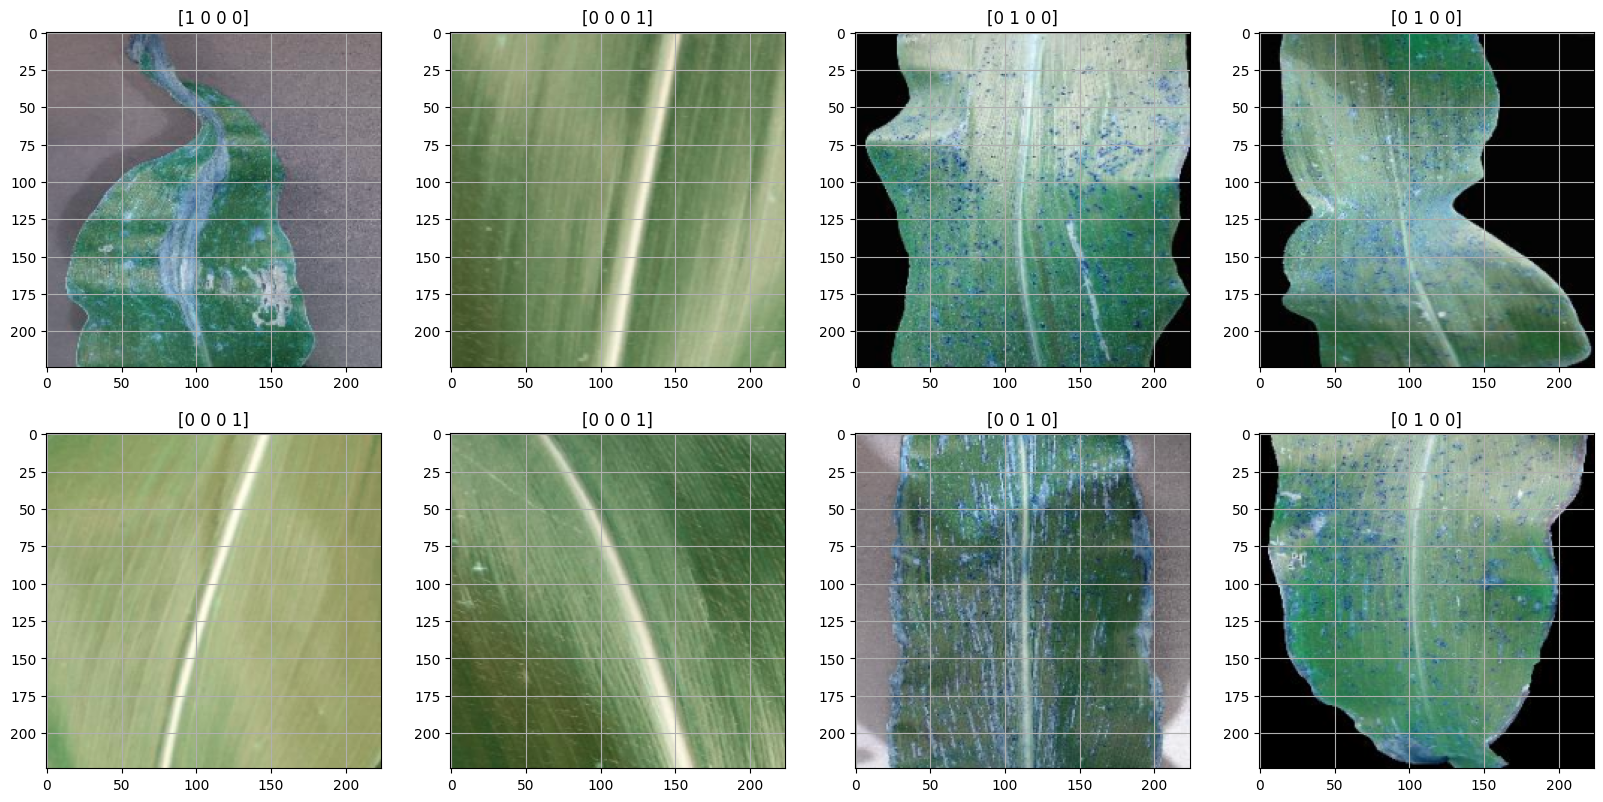

In [ ]:
import numpy as np
import pandas as pd

plt.figure(figsize=(20, 20))

for i in range(8):
  plt.subplot(4, 4, i+1)
  #In nhãn (class)
  plt.title(([y_train[i]][0]))
  plt.xticks()
  plt.yticks()
  plt.grid(True)
  #In hình
  plt.imshow(X_train[i])

plt.show()

In [ ]:
print((X_train.shape,y_train.shape))
print((X_val.shape,y_val.shape))
print((X_test.shape,y_test.shape))

((3392, 224, 224, 3), (3392, 4))
((377, 224, 224, 3), (377, 4))
((419, 224, 224, 3), (419, 4))


In [ ]:
from keras.applications.vgg16 import VGG16


def get_model():
    # Khoi tao base model
    base_model_vgg16 = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    # Khoi tao model chính
    x = base_model_vgg16.output
    # Them cac lop FC
    x = GlobalMaxPooling2D()(x)
    x = Dense(4096, activation='relu', name='fc1')(x)
    x = Dropout(0.5)(x)
    outs = Dense(4, activation='softmax', name='predictions')(x)

    # Dong bang cac Layer
    for layer in base_model_vgg16.layers:
        layer.trainable = False

    model = Model(inputs=base_model_vgg16.inputs, outputs= outs)
    # Compile
    model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])
    return model

vgg16_model = get_model()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
vgg16_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │     2,101,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,832,326 (64.21 MB)

 Trainable params: 2,117,636 (8.08 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
filepath = "/content/drive/MyDrive/Lab/Lab-Test/VGG16/model-{epoch:02d}-{val_accuracy:.2f}.keras"
checkpoint = ModelCheckpoint(filepath,
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             mode='max')
callbacks_list = [checkpoint]


In [ ]:
aug = ImageDataGenerator(
  featurewise_center=False, # Dat gia tri dau vao thanh 0 tren tap du lieu
  samplewise_center=False, #  Dat gia tri trung binh cua moi mau thanh 0
  featurewise_std_normalization=False, #  Chia dau vao cho std cua tap du lieu
  samplewise_std_normalization=False,  #  Chia moi dau vao cho std cua no
  zca_whitening=False,  # apply ZCA whitening
  rotation_range=10,  # xoay hinh anh ngau nhien trong pham vi (do, 0 den 180)
  zoom_range = 0.2, # Hinh anh thu phong ngau nhien
  width_shift_range=0.1,  # dich chuyen ngau nhien hinh anh theo chieu ngang
  height_shift_range=0.1,  # dich chuyen ngau nhien hinh anh theo chieu doc
  horizontal_flip=True,  # hinh anh lat ngau nhien
  vertical_flip=False, # hinh anh lat ngau nhien
  brightness_range=[0.2, 1.5] # dieu chinh do sang
)


In [ ]:
from tensorflow.keras.models import load_model
vgg16_model = load_model("/content/drive/MyDrive/VGG16_V08.h5")

In [ ]:
vgg16_model.compile(
optimizer=Adam(learning_rate=0.001),
loss='categorical_crossentropy',
metrics=['accuracy'])

In [ ]:
history = vgg16_model.fit(
    aug.flow(X_train, y_train, batch_size=32),
    epochs=200,
    steps_per_epoch=len(X_train) // 32,
    validation_data=aug.flow(X_val, y_val, batch_size=32),
    validation_steps=len(X_val) // 32,
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 71s 536ms/step - accuracy: 0.9439 - loss: 0.1407 - val_accuracy: 0.8949 - val_loss: 0.3253
Epoch 2/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 69s 532ms/step - accuracy: 0.9478 - loss: 0.1554 - val_accuracy: 0.9062 - val_loss: 0.6103
Epoch 3/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 55s 510ms/step - accuracy: 0.9437 - loss: 0.1625 - val_accuracy: 0.8920 - val_loss: 0.3640
Epoch 4/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 82s 517ms/step - accuracy: 0.9319 - loss: 0.1691 - val_accuracy: 0.9034 - val_loss: 0.6575
Epoch 5/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 55s 513ms/step - accuracy: 0.9285 - loss: 0.2058 - val_accuracy: 0.9119 - val_loss: 0.3027
Epoch 6/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 762ms/step - accuracy: 0.9367 - loss: 0.2017 - val_accuracy: 0.9148 - val_loss: 0.3400
Epoch 7/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 508ms/step - accuracy: 0.9476 - loss: 0.1631 - val_accuracy: 0.9006 - val_loss: 0.5826
Epoch 8/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 505ms/step - accuracy: 0.9393 -

In [ ]:
vgg16_model.save("/content/drive/MyDrive/VGG16_V09.h5")

In [ ]:
loss, acc = vgg16_model.evaluate(X_test, y_test)
print("Accuracy:", acc)
print("Loss:", loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 444ms/step - accuracy: 0.9197 - loss: 0.3671
Accuracy: 0.9164677858352661
Loss: 0.4685114622116089


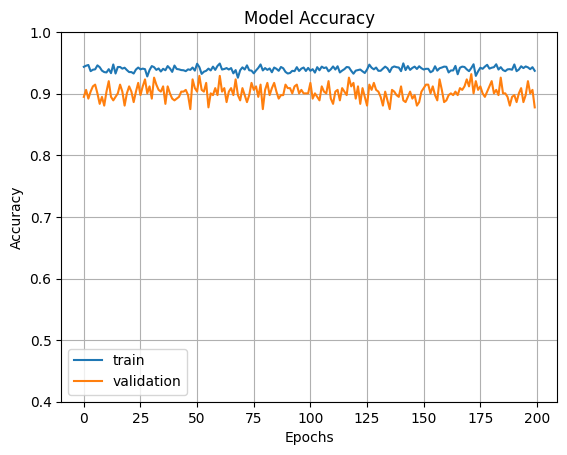

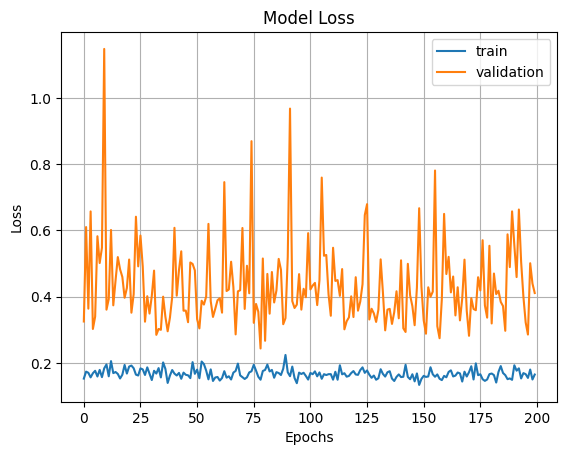

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [ ]:

#Defining function for confusion matrix plot
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Computing confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

# Visualizing
    fig, ax = plt.subplots(figsize=(7,7))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

   # Rotating the tick labels and setting their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=10, ha='right')
    # Looping over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax
np.set_printoptions(precision=2)

import tensorflow as tf
#Making prediction
y_pred = np.argmax(vgg16_model.predict(X_test), axis=-1)
y_true = np.argmax(y_test,axis=1)
#Plotting the confusion matrix
confusion_matrix(y_true, y_pred)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step


array([[113,   0,   6,   0],
       [  4, 118,   0,   0],
       [ 21,   1,  43,   0],
       [  2,   1,   0, 110]])

Confusion matrix, without normalization
              precision    recall  f1-score   support

           0       0.81      0.95      0.87       119
           1       0.98      0.97      0.98       122
           2       0.88      0.66      0.75        65
           3       1.00      0.97      0.99       113

    accuracy                           0.92       419
   macro avg       0.92      0.89      0.90       419
weighted avg       0.92      0.92      0.91       419



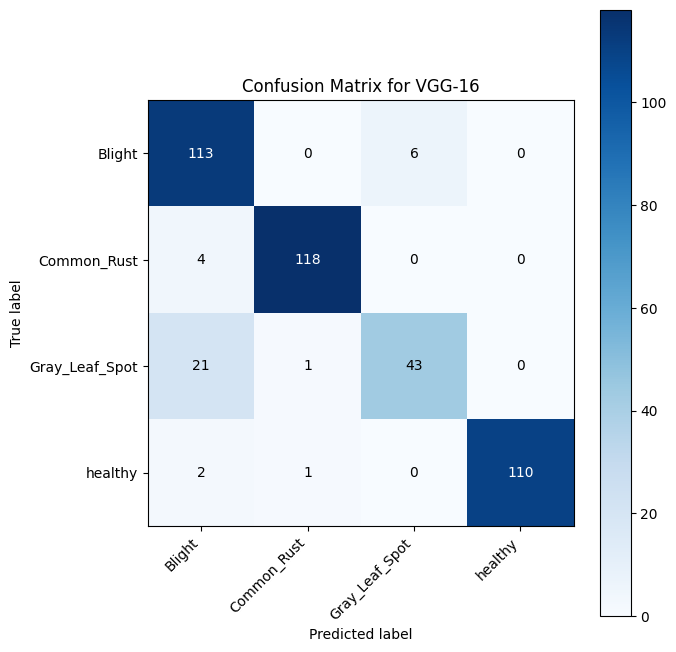

In [ ]:
class_names = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'healthy']
plot_confusion_matrix(y_true, y_pred, classes = class_names,  title = 'Confusion Matrix for VGG-16')
from sklearn import metrics
print(metrics.classification_report(y_true, y_pred, digits = 2))